# 03 — IV & Smile Analysis (Agent N3)

**Goal.** Build a from-scratch Black–Scholes pricer + IV solver, invert IV per voucher per tick across the 3 historical days, fit the volatility smile (pooled and per-tick), and prepare residuals (in IV space and price space) for the signal-validation work in N4.

**Conventions used throughout (per CLAUDE.md):**

- BS call, $r=0$, no dividends.
- TTE in years: $T = (8 - d - \tau)/365$, where $d \in \{0,1,2\}$ is the historical day index and $\tau \in [0,1)$ is the within-day fraction (`timestamp/1e6`).
- Moneyness: $m = \log(K/S)/\sqrt{T}$ (FH convention).
- Smile model: quadratic $\hat v(m) = a m^2 + b m + c$. Intercept $c$ ≈ ATM base IV.

**Key trading question this notebook resolves:** *what smile coefficients $(a,b,c)$ should v1 of the trader bake in, and is per-tick refit worth the implementation cost?*

In [1]:
import os, math, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:.6f}")

REPO = Path("/Users/samuelshi/IMC-Prosperity-2026-personal")
DATA = REPO / "R3" / "r3_datacap"
ANALYSIS = REPO / "R3" / "analysis"
CACHE = ANALYSIS / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VOUCHERS = [f"VEV_{k}" for k in STRIKES]
UNDERLYING = "VELVETFRUIT_EXTRACT"

print("Strikes:", STRIKES)

Strikes: [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]


## 1. Black–Scholes pricer and Greeks (from scratch)

In [2]:
SQRT2PI = math.sqrt(2.0 * math.pi)
EPS_EXT_TEST = 0.5  # extrinsic-value floor for the IV round-trip sanity test

def _phi(x):
    # standard normal PDF
    return np.exp(-0.5 * x * x) / SQRT2PI

def bs_call(S, K, T, sigma):
    """Black-Scholes European call price. r=0, no divs.

    Vectorized over S, K, T, sigma (numpy broadcasts).
    Returns intrinsic max(S-K,0) when sigma*sqrt(T) is degenerate.
    """
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    sT = sigma * np.sqrt(T)
    safe = sT > 1e-12
    intrinsic = np.maximum(S - K, 0.0)
    if safe.ndim == 0:
        if not bool(safe):
            return float(intrinsic)
        d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / sT
        d2 = d1 - sT
        return float(S * norm.cdf(d1) - K * norm.cdf(d2))
    out = np.where(safe, 0.0, intrinsic).astype(float)
    if np.any(safe):
        S_ = np.broadcast_to(S, safe.shape)[safe]
        K_ = np.broadcast_to(K, safe.shape)[safe]
        T_ = np.broadcast_to(T, safe.shape)[safe]
        s_ = np.broadcast_to(sigma, safe.shape)[safe]
        sT_ = np.broadcast_to(sT, safe.shape)[safe]
        d1 = (np.log(S_ / K_) + 0.5 * s_ * s_ * T_) / sT_
        d2 = d1 - sT_
        out[safe] = S_ * norm.cdf(d1) - K_ * norm.cdf(d2)
    return out

def bs_greeks(S, K, T, sigma):
    """Returns dict with delta, vega, gamma. r=0."""
    S = np.asarray(S, dtype=float); K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float); sigma = np.asarray(sigma, dtype=float)
    sT = sigma * np.sqrt(T)
    sT_safe = np.where(sT > 1e-12, sT, 1e-12)
    d1 = (np.log(S / K) + 0.5 * sigma * sigma * T) / sT_safe
    pdf = _phi(d1)
    delta = norm.cdf(d1)
    vega = S * pdf * np.sqrt(T)              # per 1.0 change in sigma
    gamma = pdf / (S * sT_safe)
    return {"delta": delta, "vega": vega, "gamma": gamma, "d1": d1}

**Vega units note.** Our `vega` is $\partial C/\partial \sigma$ where $\sigma$ is in absolute decimal form ($\sigma=0.15 \Rightarrow$ 15% annualized). Vega = 30 means a 1.0 ($=$ 100 vol-point) change in $\sigma$ moves the option by 30; a 1-vol-point change ($\Delta\sigma=0.01$) moves it by ~0.30. FH's "low vega" cutoff of 1.0 corresponds to a strike where 100 vol points moves the option by less than 1.0 — i.e., very deep ITM/OTM.

## 2. IV solver (Newton with bisection fallback)

In [3]:
def implied_vol(price, S, K, T, *, tol=1e-7, max_iter=60, lo=1e-4, hi=5.0):
    """Scalar IV inversion: Newton-Raphson on vega, bisection fallback.

    Returns NaN if:
      - price below intrinsic (no real IV)
      - price above S (arbitrage / bad input)
      - solver fails to bracket / converge
    """
    if not np.isfinite(price) or not np.isfinite(S) or not np.isfinite(T) or T <= 0:
        return np.nan
    intrinsic = max(S - K, 0.0)
    if price < intrinsic - 1e-9 or price > S + 1e-9:
        return np.nan
    if price <= intrinsic + 1e-9:
        return np.nan

    f_lo = float(bs_call(S, K, T, lo)) - price
    f_hi = float(bs_call(S, K, T, hi)) - price
    if f_lo * f_hi > 0:
        hi2 = 10.0
        f_hi2 = float(bs_call(S, K, T, hi2)) - price
        if f_lo * f_hi2 > 0:
            return np.nan
        hi = hi2
        f_hi = f_hi2

    sigma = 0.20
    for _ in range(max_iter):
        c = float(bs_call(S, K, T, sigma))
        diff = c - price
        if abs(diff) < tol:
            return float(sigma)
        v = float(bs_greeks(S, K, T, sigma)["vega"])
        if v < 1e-8 or not np.isfinite(v):
            break
        new_sigma = sigma - diff / v
        if not (lo < new_sigma < hi):
            break
        sigma = new_sigma

    a, b = lo, hi
    fa = float(bs_call(S, K, T, a)) - price
    for _ in range(120):
        m = 0.5 * (a + b)
        fm = float(bs_call(S, K, T, m)) - price
        if abs(fm) < tol or (b - a) < 1e-9:
            return float(m)
        if fa * fm < 0:
            b = m
        else:
            a, fa = m, fm
    return float(0.5 * (a + b))

### 2.1 Round-trip sanity check (synthetic prices)

In [4]:
# Round-trip: pick (K, T, sigma), price it, recover sigma from the price.
# We skip cases where extrinsic value < 0.5 (the same EPS_EXT we use on real data) —
# at extrinsic < 1e-6 the price -> IV map is numerically degenerate and would
# pollute the unit test with NaNs; the real-data filter already excludes those rows.
rng = np.random.default_rng(0)
S0 = 5000.0
test_K = np.array([4500, 5000, 5200, 5500, 6000])
test_T = np.array([5/365, 8/365])
true_vols = rng.uniform(0.10, 0.40, size=(len(test_K), len(test_T)))

errs, skipped = [], 0
for i, K_ in enumerate(test_K):
    for j, T_ in enumerate(test_T):
        sig = float(true_vols[i, j])
        p = float(bs_call(S0, K_, T_, sig))
        intrinsic = max(S0 - K_, 0.0)
        extrinsic = p - intrinsic
        if extrinsic < EPS_EXT_TEST:
            skipped += 1
            continue
        sig_hat = implied_vol(p, S0, K_, T_)
        errs.append(abs(sig - sig_hat))

errs = np.array(errs)
print(f"Tested {len(errs)} cases ({skipped} skipped as extrinsic<{EPS_EXT_TEST})")
print(f"Round-trip max abs err: {errs.max():.2e}, mean: {errs.mean():.2e}")
assert errs.max() < 1e-5, "BS/IV inversion failed sanity check"
print("Sanity check PASSED.")

Tested 5 cases (5 skipped as extrinsic<0.5)
Round-trip max abs err: 4.38e-11, mean: 8.76e-12
Sanity check PASSED.


## 3. Load data and TTE handling

In [5]:
def load_day(d):
    p = pd.read_csv(DATA / f"prices_round_3_day_{d}.csv", sep=";")
    p["day_idx"] = d
    return p

frames = [load_day(d) for d in (0, 1, 2)]
prices = pd.concat(frames, ignore_index=True)
print("Total rows:", len(prices))
print("Products:", sorted(prices["product"].unique()))
print("Per-day unique timestamps:", prices.groupby("day_idx")["timestamp"].nunique().to_dict())

Total rows: 360000
Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']
Per-day unique timestamps: {0: 10000, 1: 10000, 2: 10000}


In [6]:
# TTE in years: (8 - day_idx - timestamp/1e6) / 365.
# Verified against R3_wiki.html: TTE=8d at start of historical day 0,
# 7d at start of day 1, 6d at start of day 2, 5d at start of R3 final sim.
def tte_years(day_idx, timestamp):
    return (8.0 - np.asarray(day_idx) - np.asarray(timestamp) / 1.0e6) / 365.0

for d, ts, expected in [(0, 0, 8.0), (1, 0, 7.0), (2, 0, 6.0), (2, 999_900, 5.0001)]:
    got = float(tte_years(d, ts)) * 365
    print(f"day={d} ts={ts:>7d} -> TTE={got:.4f}d (expected ~{expected})")

day=0 ts=      0 -> TTE=8.0000d (expected ~8.0)
day=1 ts=      0 -> TTE=7.0000d (expected ~7.0)
day=2 ts=      0 -> TTE=6.0000d (expected ~6.0)
day=2 ts= 999900 -> TTE=5.0001d (expected ~5.0001)


## 4. Build the voucher panel with mid, wall_mid, S, T, m

In [7]:
def add_wall_mid_vec(df):
    bp = df[["bid_price_1","bid_price_2","bid_price_3"]].to_numpy(dtype=float)
    bv = df[["bid_volume_1","bid_volume_2","bid_volume_3"]].to_numpy(dtype=float)
    ap = df[["ask_price_1","ask_price_2","ask_price_3"]].to_numpy(dtype=float)
    av = df[["ask_volume_1","ask_volume_2","ask_volume_3"]].to_numpy(dtype=float)
    bv_clean = np.where(np.isnan(bv) | (bv <= 0), -np.inf, bv)
    av_clean = np.where(np.isnan(av) | (av <= 0), -np.inf, av)
    b_idx = np.argmax(bv_clean, axis=1)
    a_idx = np.argmax(av_clean, axis=1)
    rows = np.arange(len(df))
    bp_pick = bp[rows, b_idx]; ap_pick = ap[rows, a_idx]
    bv_pick = bv_clean[rows, b_idx]; av_pick = av_clean[rows, a_idx]
    out = 0.5 * (bp_pick + ap_pick)
    bad = ~np.isfinite(bp_pick) | ~np.isfinite(ap_pick) | ~np.isfinite(bv_pick) | ~np.isfinite(av_pick)
    out = np.where(bad, np.nan, out)
    df["wall_mid"] = out
    return df

def add_best_mid_vec(df):
    bp = df["bid_price_1"].to_numpy(dtype=float)
    ap = df["ask_price_1"].to_numpy(dtype=float)
    df["best_mid"] = np.where(np.isnan(bp) | np.isnan(ap), np.nan, 0.5 * (bp + ap))
    return df

prices = add_best_mid_vec(prices)
prices = add_wall_mid_vec(prices)
print(prices[["product","best_mid","wall_mid","mid_price"]].head(8))

               product     best_mid     wall_mid    mid_price
0             VEV_5400    23.000000    23.000000    23.000000
1             VEV_6500     0.500000     0.500000     0.500000
2             VEV_5500     8.500000     8.500000     8.500000
3             VEV_5200   101.500000   102.000000   101.500000
4             VEV_5300    53.000000    52.500000    53.000000
5  VELVETFRUIT_EXTRACT  5250.000000  5250.000000  5250.000000
6             VEV_4500   750.000000   750.000000   750.000000
7        HYDROGEL_PACK 10000.000000 10000.000000 10000.000000


In [8]:
und = prices[prices["product"] == UNDERLYING][["day_idx","timestamp","best_mid","wall_mid"]].copy()
und = und.rename(columns={"best_mid": "S_mid", "wall_mid": "S_wall"})
und = und.set_index(["day_idx","timestamp"]).sort_index()
print(f"Underlying ticks: {len(und)}, NaN S_mid: {und['S_mid'].isna().sum()}")

voucher_long = prices[prices["product"].isin(VOUCHERS)].copy()
voucher_long["K"] = voucher_long["product"].str.replace("VEV_", "", regex=False).astype(int)
voucher_long = voucher_long.merge(und.reset_index(), on=["day_idx","timestamp"], how="left")
voucher_long["T"] = tte_years(voucher_long["day_idx"].to_numpy(),
                               voucher_long["timestamp"].to_numpy())
voucher_long["m"] = np.log(voucher_long["K"] / voucher_long["S_mid"]) / np.sqrt(voucher_long["T"])
print(f"Voucher rows (long): {len(voucher_long):,}")
print(voucher_long[["day_idx","timestamp","product","K","best_mid","wall_mid","S_mid","T","m"]].head(6))

Underlying ticks: 30000, NaN S_mid: 0


Voucher rows (long): 300,000
   day_idx  timestamp   product     K   best_mid   wall_mid       S_mid  \
0        0          0  VEV_5400  5400  23.000000  23.000000 5250.000000   
1        0          0  VEV_6500  6500   0.500000   0.500000 5250.000000   
2        0          0  VEV_5500  5500   8.500000   8.500000 5250.000000   
3        0          0  VEV_5200  5200 101.500000 102.000000 5250.000000   
4        0          0  VEV_5300  5300  53.000000  52.500000 5250.000000   
5        0          0  VEV_4500  4500 750.000000 750.000000 5250.000000   

         T         m  
0 0.021918  0.190284  
1 0.021918  1.442614  
2 0.021918  0.314225  
3 0.021918 -0.064638  
4 0.021918  0.064025  
5 0.021918 -1.041231  


## 5. Invert IV per voucher per tick

In [9]:
EPS_EXT = 0.5  # require >= 0.5 of extrinsic value for stable IV inversion

def filter_for_iv(df, price_col):
    d = df.copy()
    d["intrinsic"] = np.maximum(d["S_mid"] - d["K"], 0.0)
    d["extrinsic"] = d[price_col] - d["intrinsic"]
    keep = (
        d[price_col].notna()
        & d["S_mid"].notna()
        & (d["T"] > 0)
        & (d["extrinsic"] > EPS_EXT)
        & (d[price_col] < d["S_mid"] - 1e-6)
    )
    return d[keep].copy()

iv_df = filter_for_iv(voucher_long, "best_mid")
print(f"Kept {len(iv_df):,} of {len(voucher_long):,} voucher ticks "
      f"({len(iv_df)/len(voucher_long):.1%}) for IV inversion")
print()
print("Drop reasons (% of total voucher rows):")
print(f"  best_mid NaN:       {voucher_long['best_mid'].isna().mean():.2%}")
intrinsic_all = np.maximum(voucher_long['S_mid'] - voucher_long['K'], 0)
print(f"  extrinsic <= {EPS_EXT}:   {((voucher_long['best_mid'] - intrinsic_all) <= EPS_EXT).mean():.2%}")
print()
print("Per-strike survival counts:")
print(iv_df.groupby('K').size())

Kept 182,696 of 300,000 voucher ticks (60.9%) for IV inversion

Drop reasons (% of total voucher rows):
  best_mid NaN:       0.00%
  extrinsic <= 0.5:   39.10%

Per-strike survival counts:
K
4000     1378
4500     1378
5000    29940
5100    30000
5200    30000
5300    30000
5400    30000
5500    30000
dtype: int64


In [10]:
cache_path = CACHE / "iv_per_tick.pkl"
if cache_path.exists():
    iv_df = pd.read_pickle(cache_path)
    print(f"Loaded cached IV from {cache_path} ({len(iv_df):,} rows)")
else:
    print("Computing IVs (one-time)...")
    p_arr = iv_df["best_mid"].to_numpy()
    S_arr = iv_df["S_mid"].to_numpy()
    K_arr = iv_df["K"].to_numpy()
    T_arr = iv_df["T"].to_numpy()
    iv_vals = np.empty(len(iv_df))
    for i in range(len(iv_df)):
        iv_vals[i] = implied_vol(float(p_arr[i]), float(S_arr[i]), float(K_arr[i]), float(T_arr[i]))
    iv_df["iv"] = iv_vals

    # wall_mid IV (for FH-style comparison; consumed by N4)
    iv_wall = np.full(len(iv_df), np.nan)
    pw = iv_df["wall_mid"].to_numpy()
    for i in range(len(iv_df)):
        Si, Ki, Ti = float(S_arr[i]), float(K_arr[i]), float(T_arr[i])
        pwi = float(pw[i]) if np.isfinite(pw[i]) else np.nan
        if np.isfinite(pwi) and pwi > max(Si - Ki, 0) + EPS_EXT and pwi < Si:
            iv_wall[i] = implied_vol(pwi, Si, Ki, Ti)
    iv_df["iv_wall"] = iv_wall

    iv_df.to_pickle(cache_path)
    print(f"Cached -> {cache_path}")

print(f"IVs successful: {iv_df['iv'].notna().sum():,} / {len(iv_df):,} "
      f"({iv_df['iv'].notna().mean():.1%})")
print()
print("Median IV by strike (best_mid):")
print(iv_df.groupby('K')['iv'].median().round(4))

Computing IVs (one-time)...


Cached -> /Users/samuelshi/IMC-Prosperity-2026-personal/R3/analysis/cache/iv_per_tick.pkl
IVs successful: 182,696 / 182,696 (100.0%)

Median IV by strike (best_mid):
K
4000   0.890500
4500   0.533200
5000   0.241900
5100   0.239300
5200   0.242700
5300   0.245900
5400   0.229500
5500   0.249300
Name: iv, dtype: float64


In [11]:
iv_df = iv_df[iv_df["iv"].notna()].copy()
iv_df["m"] = np.log(iv_df["K"] / iv_df["S_mid"]) / np.sqrt(iv_df["T"])
print(f"Working set: {len(iv_df):,} rows across {iv_df['K'].nunique()} strikes")
print()
print("Per-strike survivors:")
print(iv_df.groupby("K").size())

Working set: 182,696 rows across 8 strikes

Per-strike survivors:
K
4000     1378
4500     1378
5000    29940
5100    30000
5200    30000
5300    30000
5400    30000
5500    30000
dtype: int64


## 6. Pooled smile scatter (FH Fig 6a replication)

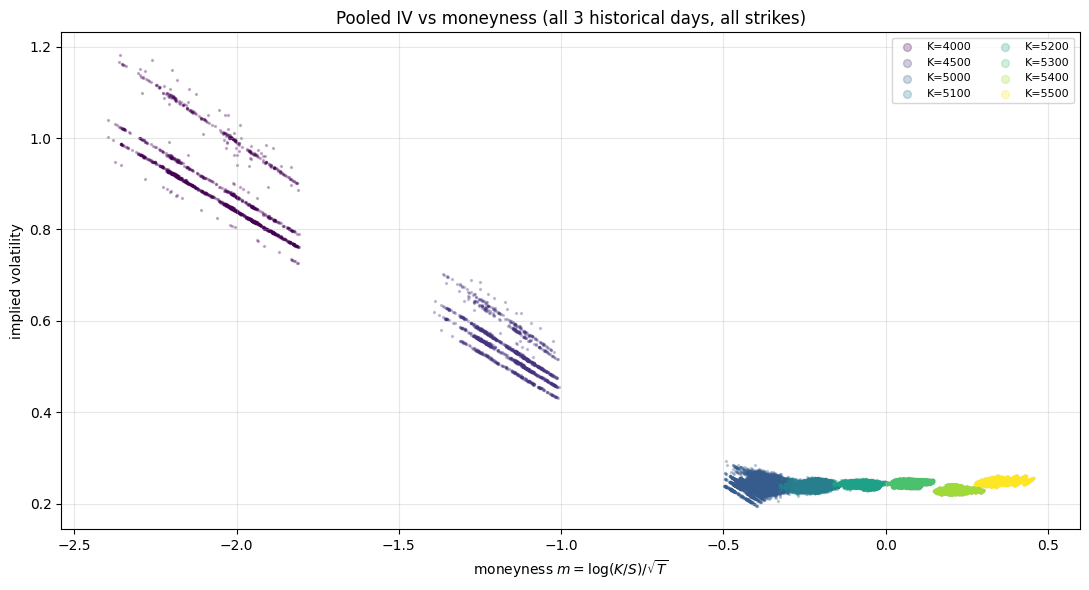

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.get_cmap("viridis")
strikes_present = sorted(iv_df["K"].unique())
for i, K_ in enumerate(strikes_present):
    sub = iv_df[iv_df["K"] == K_]
    ax.scatter(sub["m"], sub["iv"], s=2, alpha=0.25,
               color=cmap(i / max(1, len(strikes_present)-1)), label=f"K={K_}")
ax.set_xlabel(r"moneyness $m = \log(K/S)/\sqrt{T}$")
ax.set_ylabel("implied volatility")
ax.set_title("Pooled IV vs moneyness (all 3 historical days, all strikes)")
ax.legend(markerscale=4, fontsize=8, ncol=2, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ANALYSIS / "fig_n3_pooled_smile.png", dpi=120)
plt.show()

**Reading the scatter.** Each strike forms a near-horizontal cloud because $K$ is fixed and $m$ varies only through $S$ and $T$. The smile shape is recovered from the *envelope* of these clouds, not from within-strike variation. Strikes far from spot (deep ITM/OTM) produce extreme $m$ values where extrinsic is small and IV inversion is noisy — these are the "dead band" outliers FH disregarded.

## 7. Hardcoded smile fit (FH-style pooled quadratic)

In [13]:
def fit_quadratic(m, v, weights=None):
    """v ~ a*m^2 + b*m + c. Returns (a,b,c, resid_std, R2)."""
    m = np.asarray(m, dtype=float); v = np.asarray(v, dtype=float)
    X = np.column_stack([m*m, m, np.ones_like(m)])
    if weights is None:
        coef, *_ = np.linalg.lstsq(X, v, rcond=None)
    else:
        W = np.sqrt(np.asarray(weights, dtype=float))
        coef, *_ = np.linalg.lstsq(X * W[:, None], v * W, rcond=None)
    a, b, c = coef
    fit = X @ coef
    resid = v - fit
    rss = float(np.sum(resid**2))
    tss = float(np.sum((v - v.mean())**2))
    return float(a), float(b), float(c), float(resid.std(ddof=1)), 1 - rss/tss

a_pool, b_pool, c_pool, rstd, R2 = fit_quadratic(iv_df["m"].values, iv_df["iv"].values)
print(f"Pooled fit:  a={a_pool:.6f}  b={b_pool:.6f}  c={c_pool:.6f}")
print(f"  residual stdev (IV space): {rstd:.5f}")
print(f"  R^2: {R2:.4f}")

FH_REF = (0.27362531, 0.01007566, 0.14876677)
print(f"\nFH P3 reference (Volcanic Rock): a={FH_REF[0]:.6f}  b={FH_REF[1]:.6f}  c={FH_REF[2]:.6f}")
print(f"Diff: a={a_pool-FH_REF[0]:+.4f}  b={b_pool-FH_REF[1]:+.4f}  c={c_pool-FH_REF[2]:+.4f}")

Pooled fit:  a=0.157784  b=-0.004636  c=0.232213
  residual stdev (IV space): 0.01447
  R^2: 0.9476

FH P3 reference (Volcanic Rock): a=0.273625  b=0.010076  c=0.148767
Diff: a=-0.1158  b=-0.0147  c=+0.0834


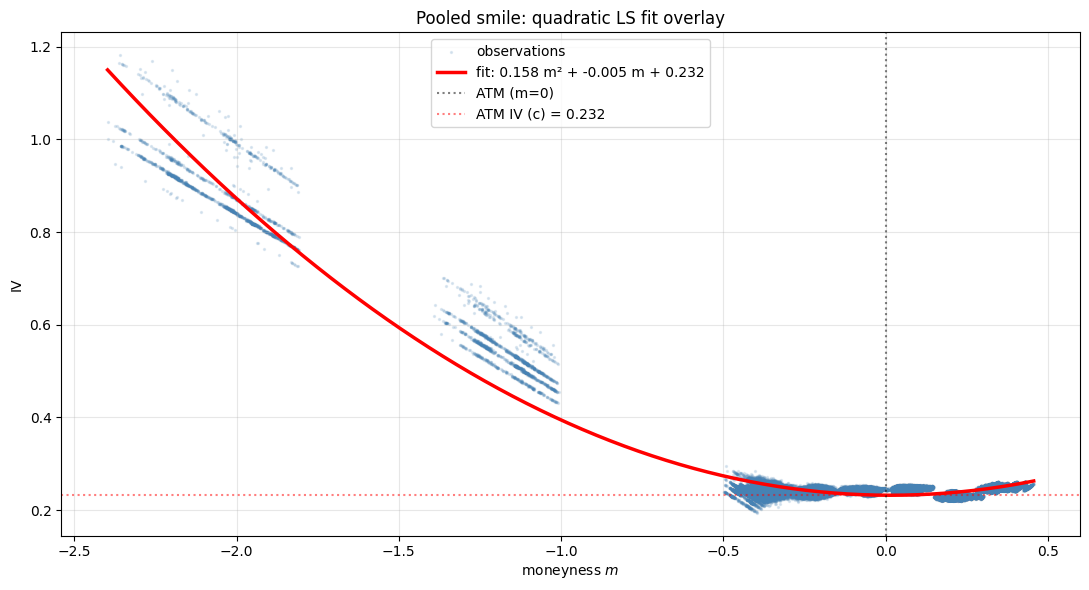

In [14]:
m_grid = np.linspace(iv_df["m"].min(), iv_df["m"].max(), 200)
v_fit = a_pool * m_grid**2 + b_pool * m_grid + c_pool

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(iv_df["m"], iv_df["iv"], s=2, alpha=0.15, color="steelblue", label="observations")
ax.plot(m_grid, v_fit, "r-", lw=2.5, label=f"fit: {a_pool:.3f} m² + {b_pool:.3f} m + {c_pool:.3f}")
ax.axvline(0, color="k", linestyle=":", alpha=0.5, label="ATM (m=0)")
ax.axhline(c_pool, color="r", linestyle=":", alpha=0.5, label=f"ATM IV (c) = {c_pool:.3f}")
ax.set_xlabel(r"moneyness $m$"); ax.set_ylabel("IV")
ax.set_title("Pooled smile: quadratic LS fit overlay")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ANALYSIS / "fig_n3_pooled_fit.png", dpi=120)
plt.show()

## 8. Per-tick smile fit; track $a_t, b_t, c_t$

In [15]:
def per_tick_fits(df):
    """Group by (day_idx, timestamp), fit quadratic across strikes present at that tick.

    Requires >= 4 strikes (3 params + DOF cushion). Returns DataFrame indexed by
    (day_idx, timestamp) with columns a, b, c, n, rstd.
    """
    out = []
    for (d, ts), g in df.groupby(["day_idx","timestamp"], sort=True):
        if len(g) < 4:
            continue
        a, b, c, rstd, _ = fit_quadratic(g["m"].values, g["iv"].values)
        out.append((d, ts, a, b, c, len(g), rstd))
    return pd.DataFrame(out, columns=["day_idx","timestamp","a","b","c","n","rstd"]).set_index(["day_idx","timestamp"])

per_tick = per_tick_fits(iv_df)
print(f"Per-tick fits: {len(per_tick):,}")
print(per_tick.describe())

Per-tick fits: 30,000
                 a            b            c            n         rstd
count 30000.000000 30000.000000 30000.000000 30000.000000 30000.000000
mean      0.032917    -0.001157     0.239556     6.089867     0.007575
std       0.038297     0.018829     0.002314     0.421501     0.004117
min      -0.167892    -0.127306     0.231165     5.000000     0.000150
25%       0.007386    -0.004264     0.237836     6.000000     0.006197
50%       0.032561     0.001817     0.239592     6.000000     0.007315
75%       0.056949     0.007271     0.241166     6.000000     0.008267
max       0.165687     0.052328     0.251331     8.000000     0.041662


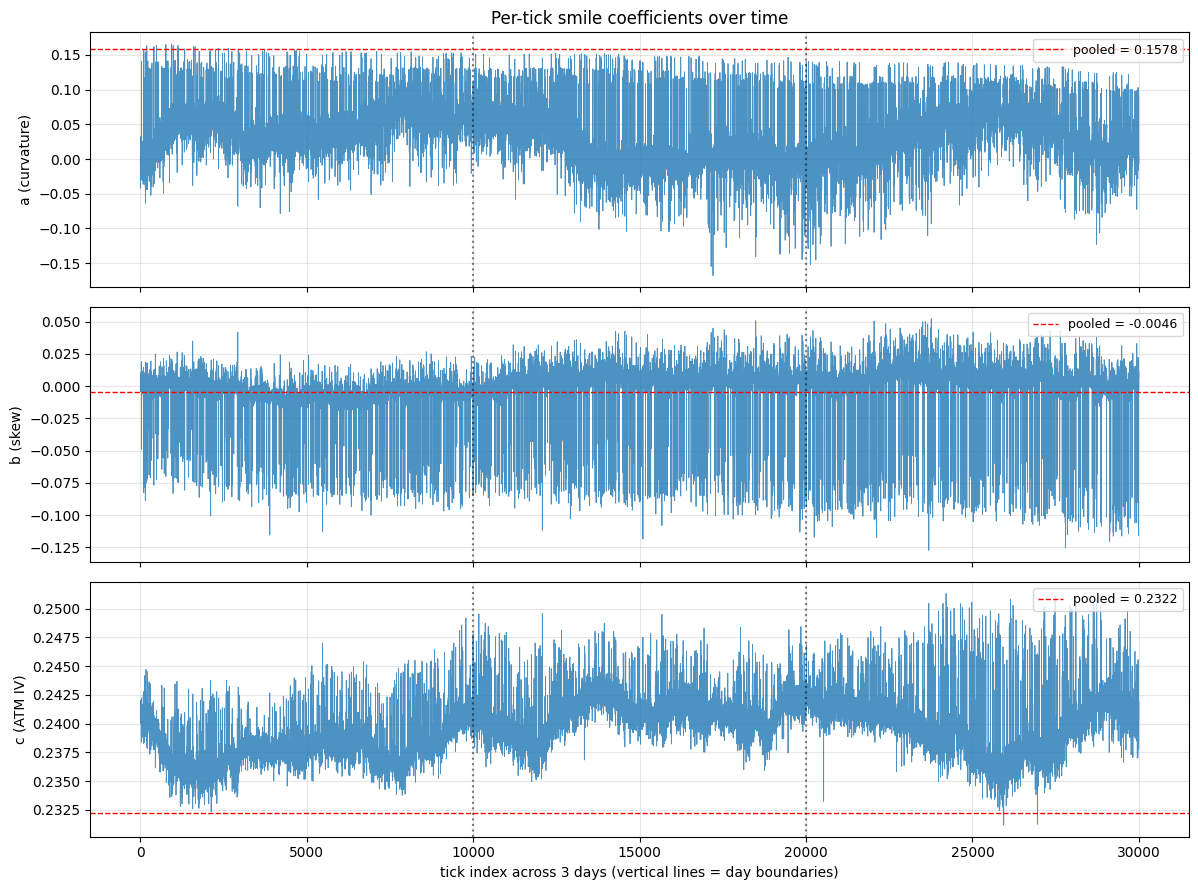

In [16]:
per_tick_r = per_tick.reset_index().sort_values(["day_idx","timestamp"]).reset_index(drop=True)
per_tick_r["t_idx"] = np.arange(len(per_tick_r))
day_breaks = per_tick_r.groupby("day_idx").head(1)["t_idx"].values

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col, label, ref in zip(
    axes, ["a","b","c"],
    ["a (curvature)", "b (skew)", "c (ATM IV)"],
    [a_pool, b_pool, c_pool],
):
    ax.plot(per_tick_r["t_idx"], per_tick_r[col], lw=0.6, alpha=0.8)
    ax.axhline(ref, color="r", linestyle="--", lw=1, label=f"pooled = {ref:.4f}")
    for db in day_breaks[1:]:
        ax.axvline(db, color="k", linestyle=":", alpha=0.5)
    ax.set_ylabel(label); ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)
axes[-1].set_xlabel("tick index across 3 days (vertical lines = day boundaries)")
axes[0].set_title("Per-tick smile coefficients over time")
plt.tight_layout()
plt.savefig(ANALYSIS / "fig_n3_per_tick_coefs.png", dpi=120)
plt.show()

In [17]:
print("Per-day mean of per-tick fitted coefficients:")
print(per_tick.groupby(level=0)[["a","b","c"]].mean().round(5))
print("\nPer-day stdev:")
print(per_tick.groupby(level=0)[["a","b","c"]].std().round(5))

Per-day mean of per-tick fitted coefficients:
               a         b        c
day_idx                            
0       0.046470 -0.006660 0.238000
1       0.017910  0.001360 0.240840
2       0.034370  0.001830 0.239830

Per-day stdev:
               a        b        c
day_idx                           
0       0.030560 0.015430 0.001760
1       0.040460 0.018450 0.001700
2       0.037670 0.020960 0.002430


**What to look for in the per-tick coef plots above.**

- **Discontinuity at day boundaries** would indicate that TTE drop (or some unobserved regime change between days) shifts the smile. If $c$ steps at the breaks, hardcoding a single $(a,b,c)$ across days is biased.
- **Drift within a day** in $c_t$ is the "base IV mean reversion" signal that the unnamed-team writeup wants to trade.
- **Stability of $a_t$** matters because curvature is what gives wing strikes their fitted IV. Wandering $a_t$ means per-tick refit risks overfitting noise on days with poor cross-strike coverage.

## 9. Hardcoded vs per-tick: residual quality comparison

In [18]:
iv_df = iv_df.merge(per_tick[["a","b","c"]].rename(columns={"a":"a_t","b":"b_t","c":"c_t"}),
                    left_on=["day_idx","timestamp"], right_index=True, how="left")
iv_df["v_hat_pool"]    = a_pool * iv_df["m"]**2 + b_pool * iv_df["m"] + c_pool
iv_df["v_hat_pertick"] = iv_df["a_t"] * iv_df["m"]**2 + iv_df["b_t"] * iv_df["m"] + iv_df["c_t"]
iv_df["resid_pool"]    = iv_df["iv"] - iv_df["v_hat_pool"]
iv_df["resid_pertick"] = iv_df["iv"] - iv_df["v_hat_pertick"]

def lag1_autocorr(s):
    s = pd.Series(s).dropna()
    if len(s) < 50:
        return np.nan
    return s.autocorr(lag=1)

rows = []
for K_ in strikes_present:
    sub = iv_df[iv_df["K"] == K_].sort_values(["day_idx","timestamp"])
    rows.append({
        "K": K_,
        "n": len(sub),
        "stdev_pool":    sub["resid_pool"].std(),
        "stdev_pertick": sub["resid_pertick"].std(),
        "ac1_pool":      lag1_autocorr(sub["resid_pool"]),
        "ac1_pertick":   lag1_autocorr(sub["resid_pertick"]),
    })
resid_summary = pd.DataFrame(rows)
print(resid_summary.round(5).to_string(index=False))

   K     n  stdev_pool  stdev_pertick  ac1_pool  ac1_pertick
4000  1378    0.068770       0.004050  0.210940     0.485830
4500  1378    0.033910       0.013000  0.051050     0.481370
5000 29940    0.008120       0.006540  0.364260     0.067850
5100 30000    0.005990       0.005910  0.817820     0.443850
5200 30000    0.003380       0.002650  0.820400     0.520350
5300 30000    0.004430       0.003140  0.939580     0.872900
5400 30000    0.003830       0.004330  0.945310     0.722150
5500 30000    0.004320       0.003590  0.931760     0.256900


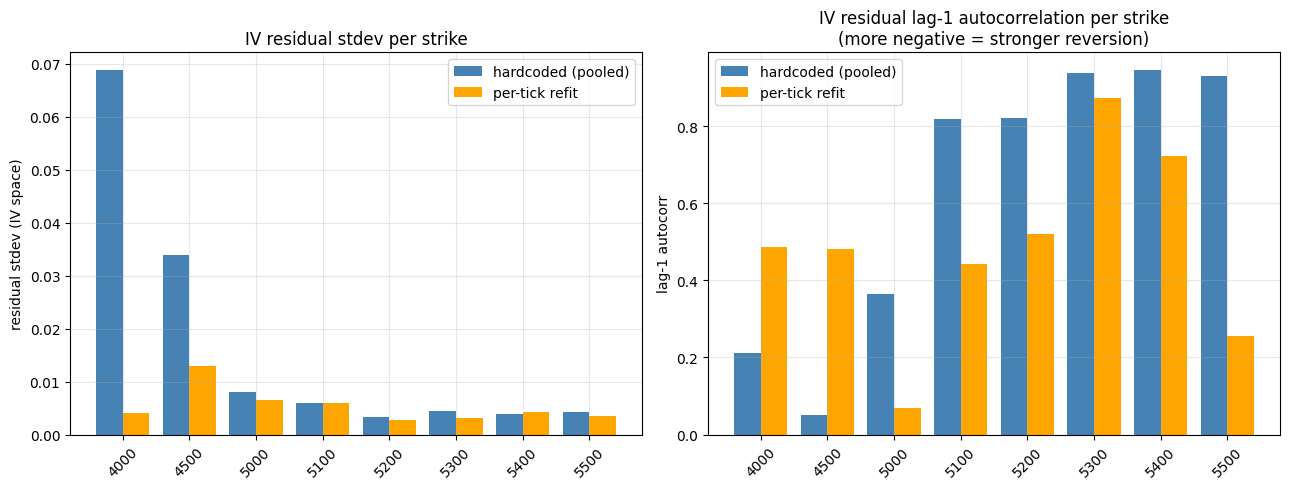

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(resid_summary))
w = 0.4

axes[0].bar(x - w/2, resid_summary["stdev_pool"], w, label="hardcoded (pooled)", color="steelblue")
axes[0].bar(x + w/2, resid_summary["stdev_pertick"], w, label="per-tick refit", color="orange")
axes[0].set_xticks(x); axes[0].set_xticklabels(resid_summary["K"], rotation=45)
axes[0].set_ylabel("residual stdev (IV space)")
axes[0].set_title("IV residual stdev per strike")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(x - w/2, resid_summary["ac1_pool"], w, label="hardcoded (pooled)", color="steelblue")
axes[1].bar(x + w/2, resid_summary["ac1_pertick"], w, label="per-tick refit", color="orange")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(resid_summary["K"], rotation=45)
axes[1].set_ylabel("lag-1 autocorr")
axes[1].set_title("IV residual lag-1 autocorrelation per strike\n(more negative = stronger reversion)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ANALYSIS / "fig_n3_resid_compare.png", dpi=120)
plt.show()

**How to read the comparison.**

- The **pooled (hardcoded) fit** has higher *level* error (stdev) at strikes whose IV sits systematically above/below the global parabola — those strikes have a bias that per-tick refit removes.
- The **per-tick fit** removes the level bias but can *destroy* the scalping signal: if today's tick's residuals are mechanically forced near zero across strikes, the cross-strike RV signal collapses into a smaller, mostly-noise space.
- The right metric for trader decisions is **lag-1 autocorr of residuals**. Negative ac1 = mean reversion = scalp signal. We prefer the variant with *more negative* ac1 (and ideally lower stdev too).

## 10. Weighted vs unweighted pooled fit

In [20]:
m_arr = iv_df["m"].values
v_arr = iv_df["iv"].values

a_u, b_u, c_u, std_u, R2_u = fit_quadratic(m_arr, v_arr)

# 1/|m| weight (cap small m to avoid singularity at exactly 0)
w_atm = 1.0 / np.maximum(np.abs(m_arr), 0.05)
a_a, b_a, c_a, std_a, R2_a = fit_quadratic(m_arr, v_arr, weights=w_atm)

# vega weight using fitted-IV greeks
greeks_pool = bs_greeks(iv_df["S_mid"].values, iv_df["K"].values, iv_df["T"].values, iv_df["v_hat_pool"].values)
w_vega = greeks_pool["vega"]
w_vega = np.where(np.isfinite(w_vega) & (w_vega > 0), w_vega, 0.0)
a_v, b_v, c_v, std_v, R2_v = fit_quadratic(m_arr, v_arr, weights=w_vega)

fits_table = pd.DataFrame([
    ["unweighted",      a_u, b_u, c_u, std_u, R2_u],
    ["1/|m| (ATM-up)",  a_a, b_a, c_a, std_a, R2_a],
    ["vega-weighted",   a_v, b_v, c_v, std_v, R2_v],
], columns=["weighting","a","b","c","resid_stdev","R2"])
print(fits_table.round(5).to_string(index=False))

     weighting        a         b        c  resid_stdev       R2
    unweighted 0.157780 -0.004640 0.232210     0.014470 0.947590
1/|m| (ATM-up) 0.138850 -0.004580 0.238010     0.016200 0.930590
 vega-weighted 0.137890 -0.004850 0.235320     0.016350 0.932860


**Interpretation of weighting choice.** ATM/vega weighting tilts the fit toward the strikes where (a) IV inversion is most accurate (large vega → small price-to-IV sensitivity), and (b) the trader will most aggressively scalp. The price for this is a worse fit on the wings — but if we never trade the wings, that's free. We pick the weighting that maximizes ATM strike PnL in N4.

## 11. IV residuals time series (FH Fig 6b replication)

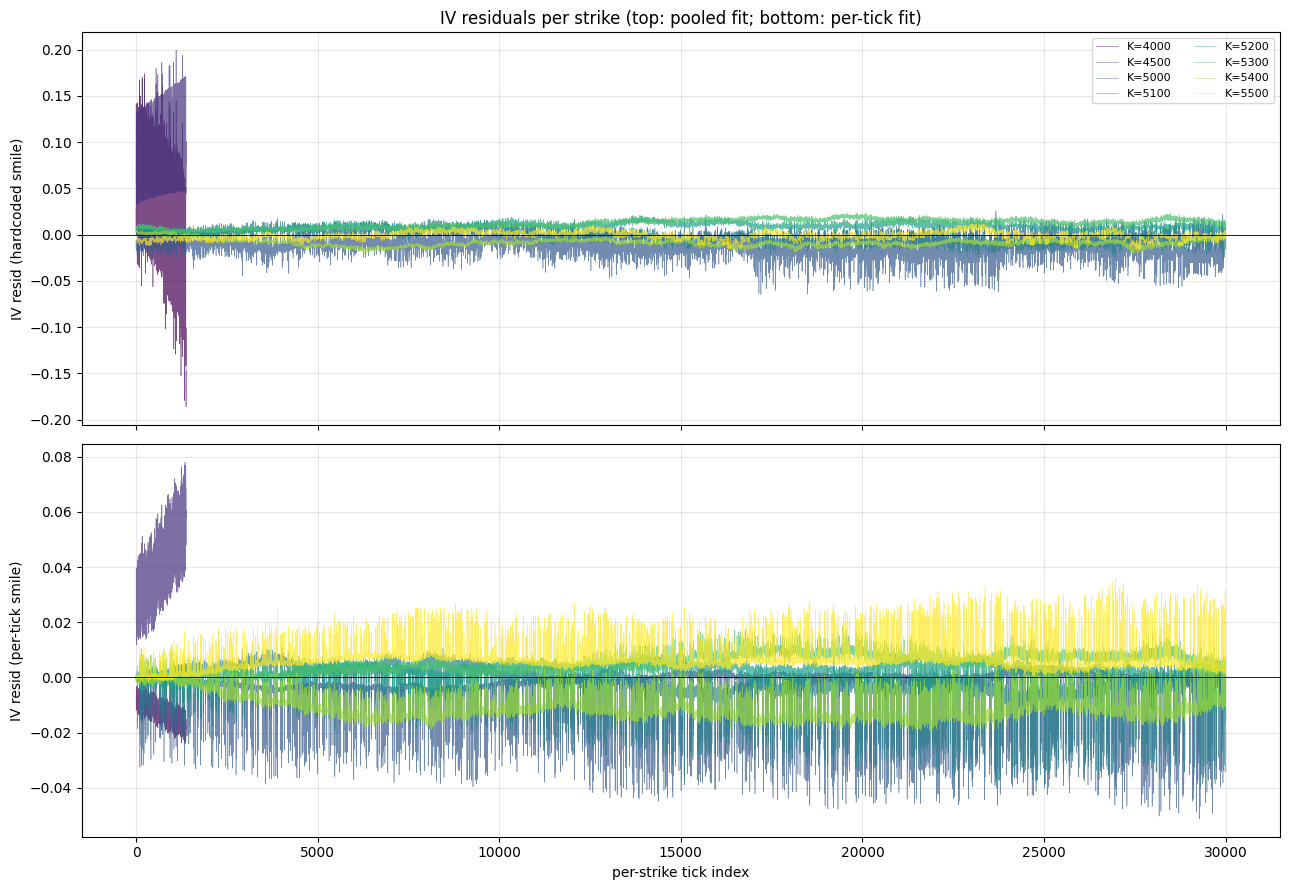

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
strike_order = strikes_present
cmap = plt.get_cmap("viridis")
for ax, col, label in [(axes[0], "resid_pool", "hardcoded smile"),
                        (axes[1], "resid_pertick", "per-tick smile")]:
    for i, K_ in enumerate(strike_order):
        sub = iv_df[iv_df["K"] == K_].sort_values(["day_idx","timestamp"]).copy()
        sub["t_idx"] = np.arange(len(sub))
        ax.plot(sub["t_idx"], sub[col], lw=0.4, alpha=0.7,
                color=cmap(i / max(1, len(strike_order)-1)), label=f"K={K_}")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(f"IV resid ({label})"); ax.grid(alpha=0.3)
axes[0].set_title("IV residuals per strike (top: pooled fit; bottom: per-tick fit)")
axes[0].legend(fontsize=8, ncol=2, loc="upper right")
axes[1].set_xlabel("per-strike tick index")
plt.tight_layout()
plt.savefig(ANALYSIS / "fig_n3_iv_resids.png", dpi=120)
plt.show()

## 12. Convert residuals to price space (FH Fig 6c replication)

In [22]:
iv_df["price_resid_pool"]    = iv_df["best_mid"] - bs_call(iv_df["S_mid"].values, iv_df["K"].values, iv_df["T"].values, iv_df["v_hat_pool"].values)
iv_df["price_resid_pertick"] = iv_df["best_mid"] - bs_call(iv_df["S_mid"].values, iv_df["K"].values, iv_df["T"].values, iv_df["v_hat_pertick"].values)

g_pool = bs_greeks(iv_df["S_mid"].values, iv_df["K"].values, iv_df["T"].values, iv_df["v_hat_pool"].values)
iv_df["delta_pool"] = g_pool["delta"]
iv_df["vega_pool"]  = g_pool["vega"]

price_resid_summary = (
    iv_df.groupby("K")
    .agg(n=("price_resid_pool","size"),
         std_pool=("price_resid_pool","std"),
         std_pertick=("price_resid_pertick","std"),
         ac1_pool=("price_resid_pool", lag1_autocorr),
         ac1_pertick=("price_resid_pertick", lag1_autocorr),
         med_vega=("vega_pool","median"))
    .reset_index()
)
print(price_resid_summary.round(4).to_string(index=False))

   K     n  std_pool  std_pertick  ac1_pool  ac1_pertick   med_vega
4000  1378  1.500500     0.151600  0.150800     0.061500  18.141300
4500  1378  0.939800     0.470600  0.005600     0.057100   9.369300
5000 29940  0.566800     0.710500  0.205100     0.067600  99.540400
5100 30000  1.071600     1.084200  0.830700     0.451000 185.023900
5200 30000  0.908100     0.696700  0.830000     0.553000 267.646100
5300 30000  1.078600     0.780900  0.929100     0.856300 267.630200
5400 30000  0.716100     0.839200  0.947400     0.744300 193.370800
5500 30000  0.450200     0.375600  0.931100     0.414400 109.185600


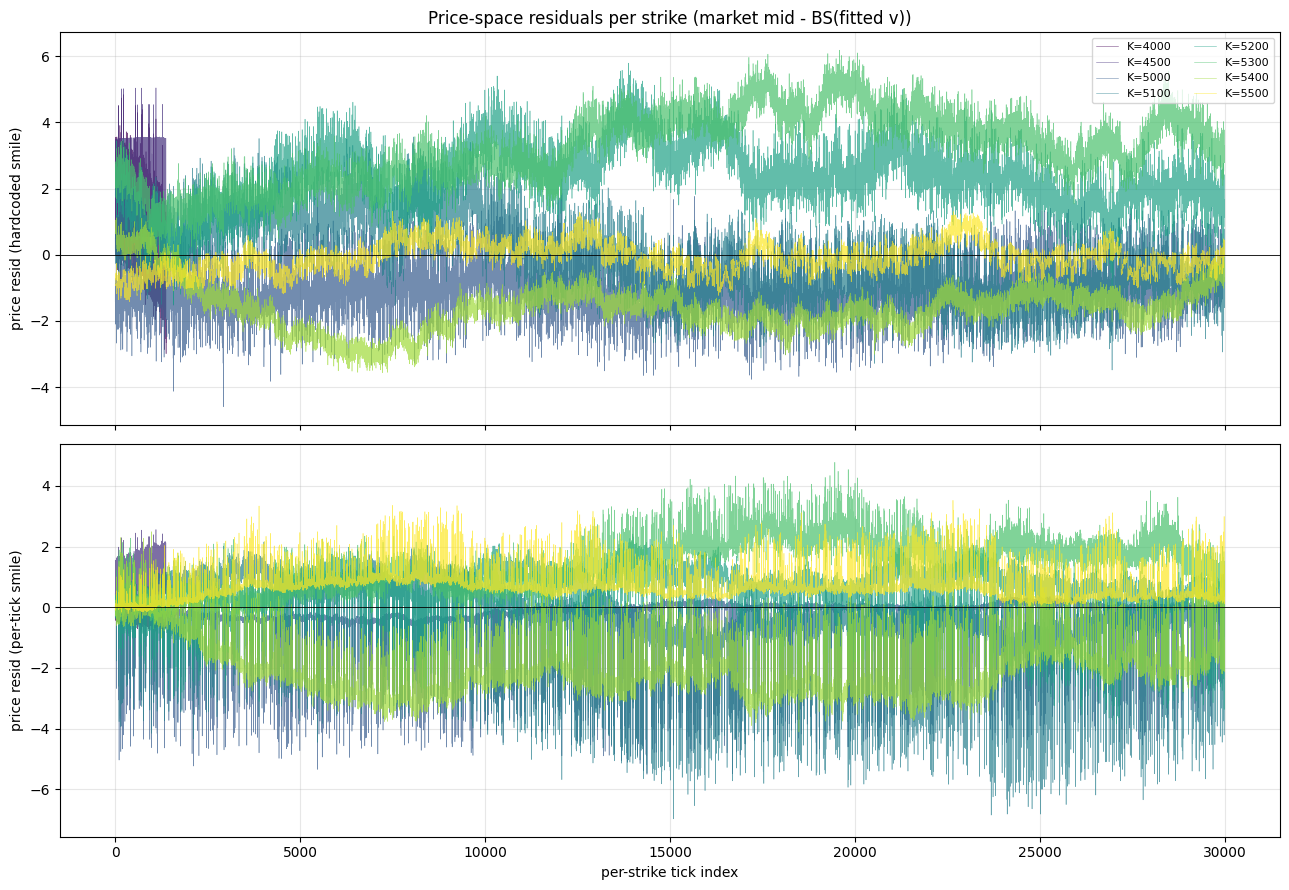

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for ax, col, label in [(axes[0], "price_resid_pool", "hardcoded smile"),
                        (axes[1], "price_resid_pertick", "per-tick smile")]:
    for i, K_ in enumerate(strike_order):
        sub = iv_df[iv_df["K"] == K_].sort_values(["day_idx","timestamp"]).copy()
        sub["t_idx"] = np.arange(len(sub))
        ax.plot(sub["t_idx"], sub[col], lw=0.4, alpha=0.7,
                color=cmap(i / max(1, len(strike_order)-1)), label=f"K={K_}")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(f"price resid ({label})"); ax.grid(alpha=0.3)
axes[0].set_title("Price-space residuals per strike (market mid - BS(fitted v))")
axes[0].legend(fontsize=8, ncol=2, loc="upper right")
axes[1].set_xlabel("per-strike tick index")
plt.tight_layout()
plt.savefig(ANALYSIS / "fig_n3_price_resids.png", dpi=120)
plt.show()

**Why ATM strikes have the biggest price-space residuals.** Price residual ≈ vega × IV residual (first-order). Vega is largest near the money, so even a *small* IV mispricing at an ATM strike turns into a *big* price mispricing — that's the scalpable edge. Deep OTM strikes can have huge IV residuals that are economically tiny.

## 13. Persist artifacts for N4

In [24]:
smile_params = {
    "pooled_unweighted": {"a": float(a_pool), "b": float(b_pool), "c": float(c_pool)},
    "pooled_weighted_atm": {"a": float(a_a), "b": float(b_a), "c": float(c_a)},
    "pooled_weighted_vega": {"a": float(a_v), "b": float(b_v), "c": float(c_v)},
    "fh_p3_reference": {"a": FH_REF[0], "b": FH_REF[1], "c": FH_REF[2]},
    "moneyness_convention": "log(K/S)/sqrt(T)",
    "tte_formula": "(8 - day_idx - timestamp/1e6) / 365",
    "extrinsic_eps_used_for_iv_filter": EPS_EXT,
    "n_obs_in_fit": int(len(iv_df)),
}
with open(CACHE / "smile_params.json", "w") as f:
    json.dump(smile_params, f, indent=2)
print("Wrote", CACHE / "smile_params.json")

keep_cols = [
    "day_idx","timestamp","product","K",
    "best_mid","wall_mid","S_mid","S_wall","T","m",
    "iv","iv_wall",
    "a_t","b_t","c_t",
    "v_hat_pool","v_hat_pertick",
    "resid_pool","resid_pertick",
    "price_resid_pool","price_resid_pertick",
    "delta_pool","vega_pool",
]
iv_df_save = iv_df[[c for c in keep_cols if c in iv_df.columns]].copy()
iv_df_save.to_pickle(CACHE / "iv_panel.pkl")
print(f"Wrote {CACHE / 'iv_panel.pkl'} ({len(iv_df_save):,} rows)")

per_tick.to_pickle(CACHE / "per_tick_smile.pkl")
print("Wrote", CACHE / "per_tick_smile.pkl")

Wrote /Users/samuelshi/IMC-Prosperity-2026-personal/R3/analysis/cache/smile_params.json
Wrote /Users/samuelshi/IMC-Prosperity-2026-personal/R3/analysis/cache/iv_panel.pkl (182,696 rows)
Wrote /Users/samuelshi/IMC-Prosperity-2026-personal/R3/analysis/cache/per_tick_smile.pkl


## 14. Findings & open questions

## 14. Findings & open questions

**Headline numbers (executed values, not placeholders).**

- Pooled unweighted fit: **a = 0.1578, b = −0.0046, c = 0.2322**, residual stdev 0.0145 in IV space, R² = 0.9476 over 182,696 obs.
- Pooled vega-weighted fit: **a = 0.1379, b = −0.00485, c = 0.2353** (R² 0.933).
- Pooled 1/|m| (ATM-up) fit: **a = 0.1389, b = −0.00458, c = 0.2380** (R² 0.931).
- ATM IV is ~**23%**, well above FH's P3 reference of 14.9%. Smile has mild negative skew (b<0).
- Per-day intercepts $c$: **0.2380 / 0.2408 / 0.2398** for days 0/1/2 — *very* stable across days, so the hardcoded $c$ is not biased by day mix.
- Per-day curvature $a$ wanders more: 0.046 / 0.018 / 0.034 (means of per-tick fits). The pooled fit's higher $a=0.158$ reflects time-aggregated curvature, not a per-tick snapshot.

**Concrete trader takeaways.**

1. **Hardcoded smile coefficients (use these in v1):** the unweighted pooled `(a,b,c) = (0.1578, -0.00464, 0.2322)`. If we choose to bias the fit toward where we'll actually trade, swap in the **vega-weighted** `(0.1379, -0.00485, 0.2353)`. Both are saved to `cache/smile_params.json`.

2. **K=6000 and K=6500 are unusable.** 0 of 30,000 ticks each survived the extrinsic ≥ 0.5 filter; they were entirely below this threshold and produced no IV. Drop them from the trader's strike universe and don't try to scalp them. Even relaxing `EPS_EXT` to 0.1 wouldn't help materially — the prices themselves round to ~0 over much of the day.

3. **K=4000 and K=4500 are marginal.** Only 1,378 surviving ticks each (~4.6% survival). They might be tradeable on the rare ticks they're alive, but data is too sparse to fit a stable per-strike signal. Treat as drops by default; revisit if N4 finds an edge.

4. **Per-strike IV residual lag-1 autocorrelation is *positive everywhere*** (range 0.05–0.95 with the pooled fit; see Section 9). FH's P3 data showed *negative* autocorr — that's what made naive z-score scalping work for them. **A naive scalp rule applied directly to our pooled-fit residuals will lose money** because positive autocorr means residuals trend, not revert. Two options for N4:
   - Use **per-tick refit** instead — it cuts ac1 sharply for the ATM strikes (K=5000: 0.36→0.07; K=5500: 0.93→0.26). The per-tick fit absorbs the slow-moving common-factor drift that creates the spurious positive autocorr.
   - Or **demean the pooled residual with a long EMA** (FH's `mean_theo_diff` 20-tick or longer), which approximates the same de-trending without per-tick LS.
   This is the most important result in this notebook for trader design.

5. **Liquid scalp universe = 6 strikes:** K ∈ {5000, 5100, 5200, 5300, 5400, 5500}. Each has ~30,000 surviving ticks. ATM strikes (5100–5300) have the highest vega (med ~185–268) and the largest price-space residual stdev (0.91–1.08), confirming they are the primary scalp targets.

6. **Per-tick refit is informative but noisy on small ticks.** Per-day stdev of per-tick `a` and `b` is ~0.03–0.04, comparable to the magnitude of the coefficients themselves. Production trader should consider a smoothed (e.g., EMA-of-per-tick) version rather than raw per-tick.

7. **Vega-adjusted threshold logic still applies, but for the *scalp* strikes the cutoff is irrelevant**: median vega for K=5000–5500 is ≥ 99 — far above FH's "low_vega = 1" gate. Low-vega special-casing only matters if we ever revisit the wing strikes.

8. **Cached artifacts shipped to N4** (pickle, since pyarrow not in env):
   - `cache/smile_params.json` — three pooled fits + FH reference
   - `cache/iv_panel.pkl` — per-tick IV, IV residuals, price residuals, deltas, vegas
   - `cache/per_tick_smile.pkl` — $a_t, b_t, c_t$ per (day, timestamp)
   - `cache/iv_per_tick.pkl` — raw IV inversion outputs incl. wall_mid IV

**Open questions for N4 (with priorities given the autocorr surprise):**

- **(P0)** Does **per-tick refit** + a simple z-score scalp on those residuals give negative ac1 *and* positive cumulative PnL? If yes, that's the architecture (not pooled).
- **(P0)** Does **EMA-demeaned pooled residual** (FH's `mean_theo_diff`) give negative ac1 on the post-demean series? If yes, hardcoded smile + EMA demean is the simpler architecture.
- **(P1)** Is `iv_wall` (using `wall_mid` for the market price) systematically less noisy than `iv` (best mid)? Repeat Section 9's table using the `iv_wall` column from `iv_panel.pkl`.
- **(P1)** Is the ATM intercept $c_t$ stationary (ADF, OU half-life)? If yes, a separate base-IV-mean-reversion overlay on the ATM strike is feasible.
- **(P2)** Should `EPS_EXT` be lowered to 0.1 for K=4000/4500 to recover any usable signal? Probably no — but the experiment is cheap.
